# Standardizing the shape of spatial datasets before Vitessce

Script that re-shapes the E11 pre-processed AnnData object from STARmap/SPARTseq to become horizontally aligned by slice. 
Also reduces space b/n individual slices in each dataset manually, and exports the dataset. 

**Input:** AnnData Object for Spatial Data 

**Output:** AnnData Object for Spatial Data

In [64]:
import anndata as ad 
import scanpy as sc
import numpy as np
import pandas as pd 
import matplotlib as mpl
from matplotlib import rcParams
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
import os

from vitessce import (
    VitessceConfig,
    Component as cm,
    CoordinationType as ct,
    AnnDataWrapper,
)
from vitessce.data_utils import (
    optimize_adata,
    VAR_CHUNK_SIZE,
)

warnings.simplefilter(action="ignore", category=Warning)

sc.set_figure_params(facecolor="white", figsize=(8, 8))
sc.settings.verbosity = 3

print("All packages loaded successfully!")

path = "/Users/iriskwon/Desktop/mouse-cereb-dev/"
os.chdir(path)
# verify the change
print("New working directory:", os.getcwd())

sc.logging.print_header()
sc.set_figure_params(facecolor="white", figsize=(8, 8))
sc.settings.verbosity = 3

All packages loaded successfully!
New working directory: /Users/iriskwon/Desktop/mouse-cereb-dev
scanpy==1.10.3 anndata==0.10.9 umap==0.5.7 numpy==1.26.4 scipy==1.13.1 pandas==2.2.3 scikit-learn==1.6.1 statsmodels==0.14.4 pynndescent==0.5.13


In [65]:
# Load data 
e11_data = ad.read_h5ad("data_for_vitessce/e11_cell_types_4-13-25.h5ad")

In [66]:
e11_data.obs['library_id'].unique()

['e11_1', 'e11_2', 'e11_3', 'e11_4']
Categories (4, object): ['e11_1', 'e11_2', 'e11_3', 'e11_4']

In [67]:
e11_data

AnnData object with n_obs × n_vars = 25341 × 1742
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'cell_types', 'finer_cell_types'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'mean', 'std'
    uns: 'cell_types_colors', 'finer_cell_types_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial', 'spatial3d'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [68]:
pd.DataFrame(e11_data.obsm["spatial"], columns=["x", "y"]).describe()

,x,y
count,25341.000000,25341.000000
mean,9437.373462,16983.115537
std,4795.672392,10830.871281
min,0.000000,0.000000
25%,5001.836225,10521.145046
50%,9859.431165,18203.677656
75%,13657.721485,23454.382256
max,18185.584848,35048.450140


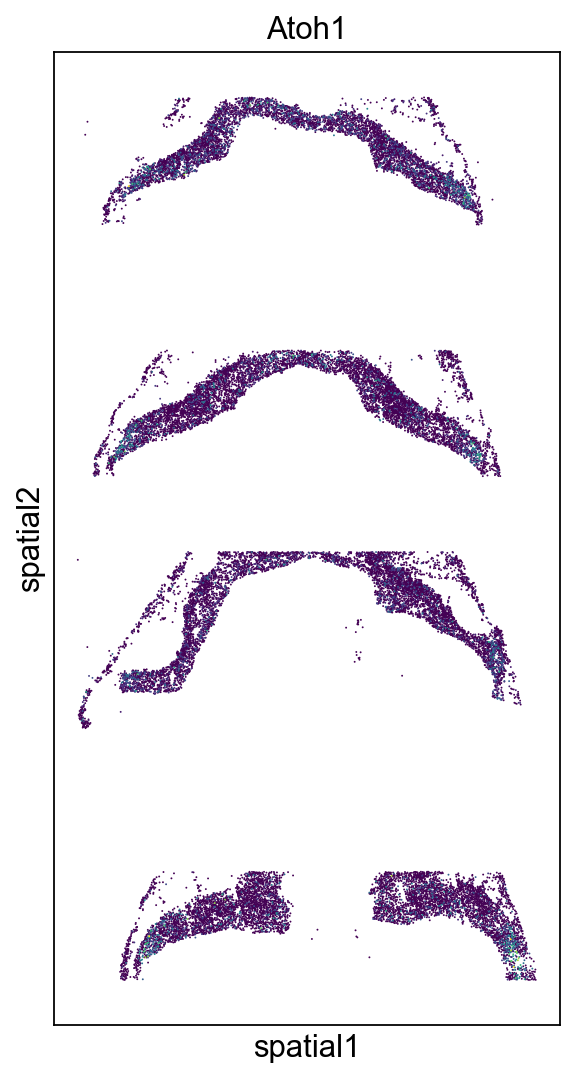

In [69]:
# Plot original spatial 
sc.pl.spatial(e11_data, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [70]:
# Iterate through each library_id and subset the data
library_subsets = {}
for lib_id in e11_data.obs['library_id'].unique():
    # Create a mask for the current library_id
    mask = e11_data.obs['library_id'] == lib_id
    
    # Subset the AnnData object
    library_subsets[lib_id] = e11_data[mask].copy()
    
    # Extract x and y coordinates for the current library_id
    x_coords = library_subsets[lib_id].obsm['spatial'][:, 0]
    y_coords = library_subsets[lib_id].obsm['spatial'][:, 1]
    
    print(f"Library ID: {lib_id}")
    print(f"X Coordinates: {x_coords[:5]}")  # Print first 5 x-coordinates
    print(f"Y Coordinates: {y_coords[:5]}")  # Print first 5 y-coordinates

Library ID: e11_1
X Coordinates: [ 5422.58689763  4800.16197544 16567.22158286  7315.65829814
  6023.99824072]
Y Coordinates: [32275.02778796 32462.45496694 32011.87056457 31578.2767136
 32133.25418484]
Library ID: e11_2
X Coordinates: [ 5381.94828936  7156.57406316 11570.66120489  5008.65109662
  4004.37975459]
Y Coordinates: [18967.783355   18075.9934789  18342.27964925 19533.72613915
 22263.57884241]
Library ID: e11_3
X Coordinates: [12830.75683328  6665.62576938 12885.5877379  12809.74679178
  6123.91745285]
Y Coordinates: [12444.54039741 10890.73722117 12454.26330798 12438.32740445
 10808.35447578]
Library ID: e11_4
X Coordinates: [12377.0880753   4419.35903537  9896.70288405  8751.1013511
  5411.1800502 ]
Y Coordinates: [1965.09019817 2028.38281258 1268.31816077  927.31001833 1183.15957982]


Checking original data

In [71]:
e11_2_mask = e11_data.obs['library_id'] == 'e11_2'

In [72]:
# 'top' represents to all cells in df that are not in e11_2 
e11_2_mask.describe(include='all')

count     25341
unique        2
top       False
freq      18310
Name: library_id, dtype: object

In [73]:
# Cell count of e11_2
e11_2_mask.sum()

7031

In [74]:
# subset the anndata obj to only include e11_2 slice 
e11_2 = e11_data[e11_2_mask].copy()

In [75]:
# Extract x and y coordinates for the current library_id
x_coords = e11_2.obsm['spatial'][:, 0]
y_coords = e11_2.obsm['spatial'][:, 1]

In [76]:
e11_2.obsm['spatial'][1]

array([ 7156.57406316, 18075.9934789 ])

In [77]:
print(f"Min x for e11_2: {min(x_coords)}")
print(f"Max x for e11_2: {max(x_coords)}")

print(f"Min y for e11_2: {min(y_coords)}")
print(f"Max y for e11_2: {max(y_coords)}")

Min x for e11_2: 0.0
Max x for e11_2: 17587.66306155601
Min y for e11_2: 18049.14008407484
Max y for e11_2: 25048.20518269773


In [78]:
e11_1 = e11_data[e11_data.obs['library_id'] == 'e11_1'].copy()
e11_3 = e11_data[e11_data.obs['library_id'] == 'e11_3'].copy()
e11_4 = e11_data[e11_data.obs['library_id'] == 'e11_4'].copy()

In [79]:
# Extract x and y coordinates for the current library_id
x_coords = e11_1.obsm['spatial'][:, 0]
y_coords = e11_1.obsm['spatial'][:, 1]

print(f"Min x for e11_1: {min(x_coords):.0f}")
print(f"Max x for e11_1: {max(x_coords):.0f}")

print(f"Min y for e11_1: {min(y_coords):.0f}")
print(f"Max y for e11_1: {max(y_coords):.0f}")

Min x for e11_1: 1680
Max x for e11_1: 18186
Min y for e11_1: 30750
Max y for e11_1: 35048


In [80]:
# Extract x and y coordinates for the current library_id
x_coords = e11_2.obsm['spatial'][:, 0]
y_coords = e11_2.obsm['spatial'][:, 1]

print(f"Min x for e11_2: {min(x_coords):.0f}")
print(f"Max x for e11_2: {max(x_coords):.0f}")

print(f"Min y for e11_2: {min(y_coords):.0f}")
print(f"Max y for e11_2: {max(y_coords):.0f}")

Min x for e11_2: 0
Max x for e11_2: 17588
Min y for e11_2: 18049
Max y for e11_2: 25048


In [81]:
# Extract x and y coordinates for the current library_id
x_coords = e11_3.obsm['spatial'][:, 0]
y_coords = e11_3.obsm['spatial'][:, 1]

print(f"Min x for e11_3: {min(x_coords):.0f}")
print(f"Max x for e11_3: {max(x_coords):.0f}")

print(f"Min y for e11_3: {min(y_coords):.0f}")
print(f"Max y for e11_3: {max(y_coords):.0f}")

Min x for e11_3: 625
Max x for e11_3: 16778
Min y for e11_3: 10051
Max y for e11_3: 15040


In [82]:
# Extract x and y coordinates for the current library_id
x_coords = e11_4.obsm['spatial'][:, 0]
y_coords = e11_4.obsm['spatial'][:, 1]

print(f"Min x for e11_4: {min(x_coords):.0f}")
print(f"Max x for e11_4: {max(x_coords):.0f}")

print(f"Min y for e11_4: {min(y_coords):.0f}")
print(f"Max y for e11_4: {max(y_coords):.0f}")

Min x for e11_4: 295
Max x for e11_4: 16467
Min y for e11_4: 0
Max y for e11_4: 5048


In [83]:
# subtract all coordinates in each Anndata object by min x and y values 
# List of AnnData objects
adatas_list = [e11_1, e11_2, e11_3, e11_4]  # Replace with your actual AnnData objects

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = adata.obsm["spatial"]
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Subtract min_x and min_y from all coordinates
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Verify the adjustment for one dataset
print("Adjusted spatial coordinates for e11_1:")
print(e11_1.obsm["spatial"][:10])

Adjusted spatial coordinates for e11_1:
[[ 3742.10046066  1525.4433859 ]
 [ 3119.67553848  1712.87056488]
 [14886.73514589  1262.28616251]
 [ 5635.17186118   828.69231154]
 [ 4343.51180376  1383.66978278]
 [ 4107.81788741  1437.15690481]
 [12716.31670911   706.74887414]
 [ 4622.45049324  1311.18845538]
 [ 3922.87875269  1500.38926369]
 [ 4131.90870265   800.24870783]]


In [84]:
pd.DataFrame(e11_4.obsm["spatial"], columns=["x", "y"]).describe()

,x,y
count,5697.000000,5697.000000
mean,8691.945684,2080.738603
std,4326.303828,1155.696474
min,0.000000,0.000000
25%,4814.882359,1053.616198
50%,8854.571051,2119.356662
75%,12594.111097,2965.702886
max,16172.604337,5048.450140


In [85]:
e11_4

AnnData object with n_obs × n_vars = 5697 × 1742
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'cell_types', 'finer_cell_types'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'mean', 'std'
    uns: 'cell_types_colors', 'finer_cell_types_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial', 'spatial3d'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

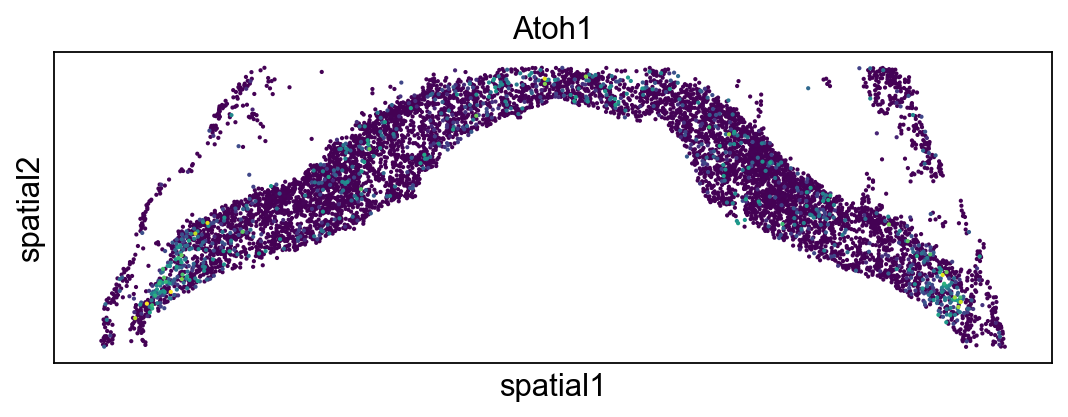

In [86]:
sc.pl.spatial(e11_3, spot_size = 75, color = "Atoh1", colorbar_loc = None)

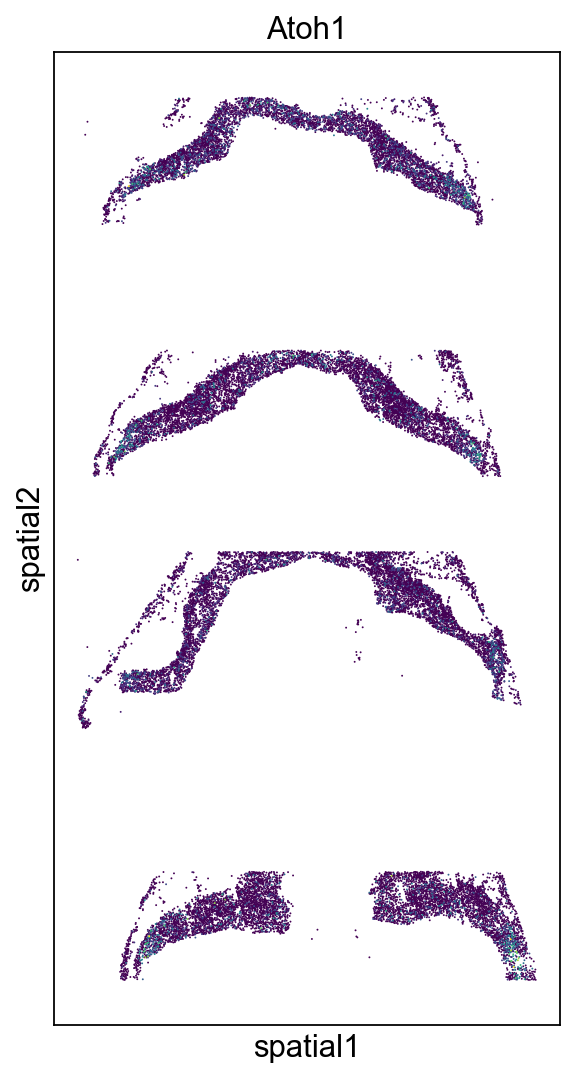

In [87]:
sc.pl.spatial(e11_data, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [88]:
import copy
import anndata as ad


# List of AnnData objects
adatas_list = [e11_1, e11_2]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 1500 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
e11_1_2_combined = ad.concat(adatas_list, join="outer", label="batch", keys=["e11_1", "e11_2"])

# Verify the combined AnnData object
print(e11_1_2_combined)
print(e11_1_2_combined.obsm["spatial"][:10])

AnnData object with n_obs × n_vars = 13064 × 1742
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'cell_types', 'finer_cell_types'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial', 'spatial3d'
[[ 3742.10046066  1525.4433859 ]
 [ 3119.67553848  1712.87056488]
 [14886.73514589  1262.28616251]
 [ 5635.17186118   828.69231154]
 [ 4343.51180376  1383.66978278]
 [ 4107.81788741  1437.15690481]
 [12716.31670911   706.74887414]
 [ 4622.45049324  1311.18845538]
 [ 3922.87875269  1500.38926369]
 [ 4131.90870265   800.24870783]]


In [89]:
16172 + 16152 + 17587 + 16505

66416

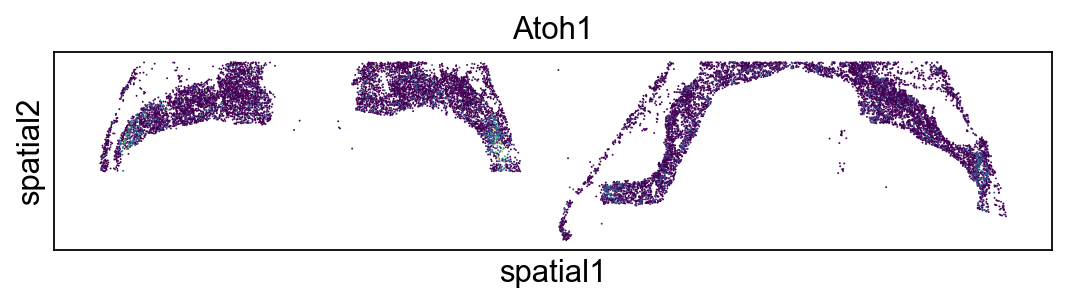

In [90]:
sc.pl.spatial(e11_1_2_combined, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [91]:
import copy
import anndata as ad


# List of AnnData objects
adatas_list = [e11_3, e11_4]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 1500 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
e11_3_4_combined = ad.concat(adatas_list, join="outer", label="batch", keys=["e11_3", "e11_4"])

# Verify the combined AnnData object
print(e11_3_4_combined)
print(e11_3_4_combined.obsm["spatial"][:10])

AnnData object with n_obs × n_vars = 12277 × 1742
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'cell_types', 'finer_cell_types'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial', 'spatial3d'
[[12206.03524291  2393.65185826]
 [ 6040.90417901   839.84868202]
 [12260.86614753  2403.37476883]
 [12185.02520141  2387.4388653 ]
 [ 5499.19586248   757.46593663]
 [12584.43584895  2461.76798938]
 [ 5410.40619032   735.09161288]
 [ 4312.69215782  2420.31238878]
 [ 5444.83724081   737.61095699]
 [13161.36430508  2571.08766173]]


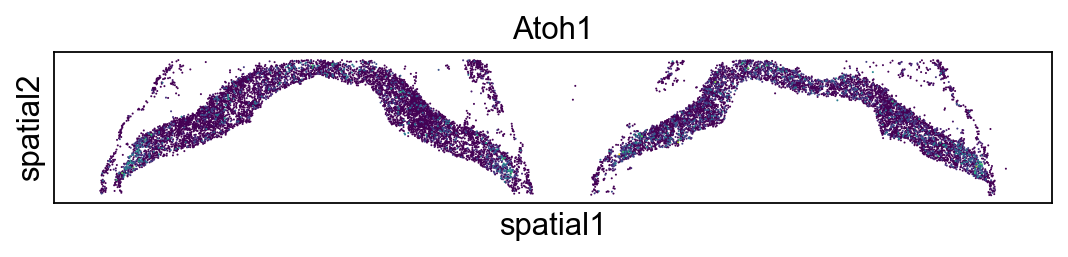

In [92]:
sc.pl.spatial(e11_3_4_combined, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [93]:
import copy
import anndata as ad


# List of AnnData objects
adatas_list = [e11_1_2_combined, e11_3_4_combined]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 1500 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
e11_combined = ad.concat(adatas_list, join="outer", label="batch", keys=["e11_1", "e11_2", "e11_3", "e11_4"])

# Verify the combined AnnData object
print(e11_combined)
print(e11_combined.obsm["spatial"][:10])

AnnData object with n_obs × n_vars = 25341 × 1742
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'cell_types', 'finer_cell_types'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial', 'spatial3d'
[[ 3742.10046066  1525.4433859 ]
 [ 3119.67553848  1712.87056488]
 [14886.73514589  1262.28616251]
 [ 5635.17186118   828.69231154]
 [ 4343.51180376  1383.66978278]
 [ 4107.81788741  1437.15690481]
 [12716.31670911   706.74887414]
 [ 4622.45049324  1311.18845538]
 [ 3922.87875269  1500.38926369]
 [ 4131.90870265   800.24870783]]


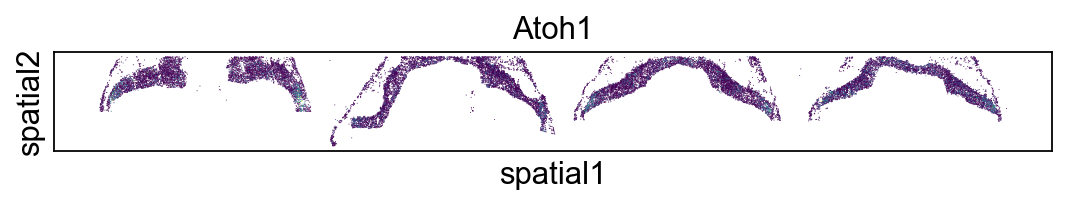

In [94]:
sc.pl.spatial(e11_combined, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [95]:
os.getcwd()

'/Users/iriskwon/Desktop/mouse-cereb-dev'

In [96]:
e11_combined

AnnData object with n_obs × n_vars = 25341 × 1742
    obs: 'cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'cell_types', 'finer_cell_types'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial', 'spatial3d'

In [97]:
# Rename an observation variable in the AnnData object
e11_combined.obs.rename(columns={"cell_types": "broad_cell_types"}, inplace=True)
e11_combined.obs.rename(columns={"finer_cell_types": "cell_types"}, inplace=True)

# Verify the change
print(e11_combined.obs.columns)

Index(['cell_number', 'library_id', 'timepoint', 'batch', 'n_genes_by_counts',
       'total_counts', 'n_counts', 'leiden', 'broad_cell_types', 'cell_types'],
      dtype='object')


In [98]:
import pandas as pd
pd.DataFrame(e11_combined.obsm["spatial"], columns=["x", "y"]).describe()

,x,y
count,25341.000000,25341.000000
mean,35743.490946,2044.849754
std,20330.233766,1323.101291
min,0.000000,0.000000
25%,20070.671013,984.254658
50%,34567.314686,1883.399852
75%,51424.020592,2881.361615
max,70918.289885,6999.065099


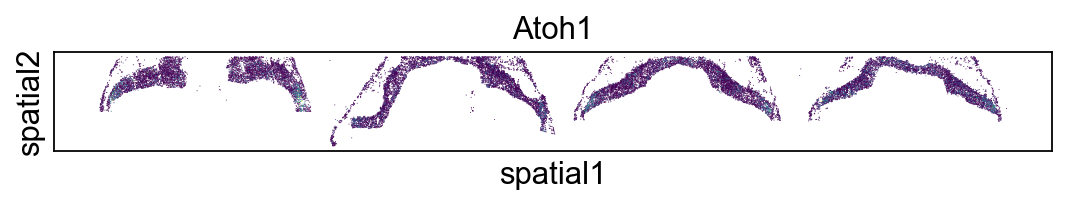

In [100]:
sc.pl.spatial(e11_combined, spot_size=75, colorbar_loc = None, color = "Atoh1")

In [101]:
e11_combined.write("data_for_vitessce/e11_data.h5ad")

Also modify spacing between other Timepoint datasets: 

# E13

In [164]:
# Load data 
e13_data = ad.read_h5ad("data_for_vitessce/e13_data.h5ad")

In [165]:
e13_data

AnnData object with n_obs × n_vars = 47025 × 1731
    obs: 'cell_number', 'library_id', 'timepoint', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'broad_cell_types', 'cell_types'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'mean', 'std'
    uns: 'cell_types_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial', 'spatial3d'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [166]:
e13_data.obs['library_id'].unique()

['e13_B1', 'e13_B3', 'e13_B5', 'e13_C5']
Categories (4, object): ['e13_B1', 'e13_B3', 'e13_B5', 'e13_C5']

In [167]:
e13_B1 = e13_data[e13_data.obs['library_id'] == 'e13_B1'].copy()
e13_B3 = e13_data[e13_data.obs['library_id'] == 'e13_B3'].copy()
e13_B5 = e13_data[e13_data.obs['library_id'] == 'e13_B5'].copy()
e13_C5 = e13_data[e13_data.obs['library_id'] == 'e13_C5'].copy()

In [119]:
e13_B1

AnnData object with n_obs × n_vars = 13789 × 1731
    obs: 'cell_number', 'library_id', 'timepoint', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'broad_cell_types', 'cell_types'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'mean', 'std'
    uns: 'cell_types_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial', 'spatial3d'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [170]:
import copy
import anndata as ad


# List of AnnData objects
adatas_list = [e13_B1, e13_B3]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 1200 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
e13_1_2 = ad.concat(adatas_list, join="outer", label="batch", keys=["e13_B1", "e13_B3"])

# Verify the combined AnnData object
print(e13_1_2)
#print(e11_combined.obsm["spatial"][:10])

AnnData object with n_obs × n_vars = 27019 × 1731
    obs: 'cell_number', 'library_id', 'timepoint', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'broad_cell_types', 'cell_types', 'batch'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial', 'spatial3d'


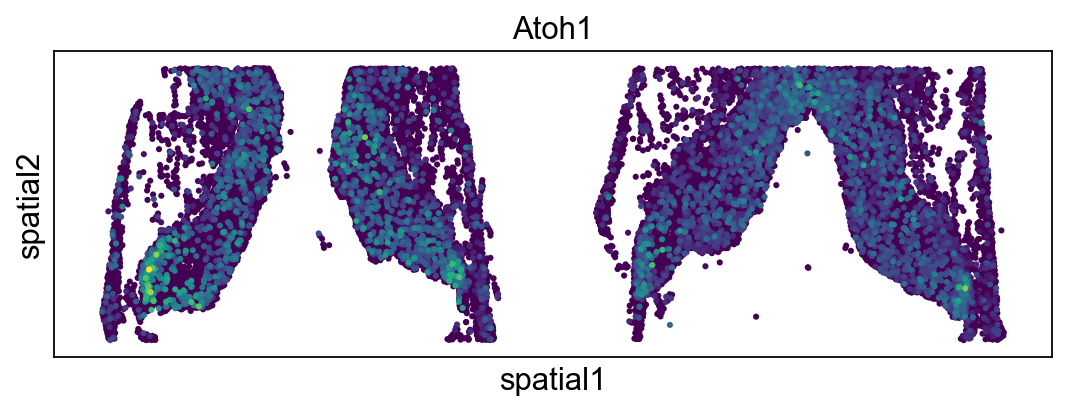

In [ ]:
sc.pl.spatial(e13_1_2, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [172]:
import copy
import anndata as ad


# List of AnnData objects
adatas_list = [e13_B5, e13_C5]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 1200 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
e13_3_4 = ad.concat(adatas_list, join="outer", label="batch", keys=["e13_B5", "e13_C5"])

# Verify the combined AnnData object
print(e13_3_4)
#print(e11_combined.obsm["spatial"][:10])

AnnData object with n_obs × n_vars = 20006 × 1731
    obs: 'cell_number', 'library_id', 'timepoint', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'broad_cell_types', 'cell_types', 'batch'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial', 'spatial3d'


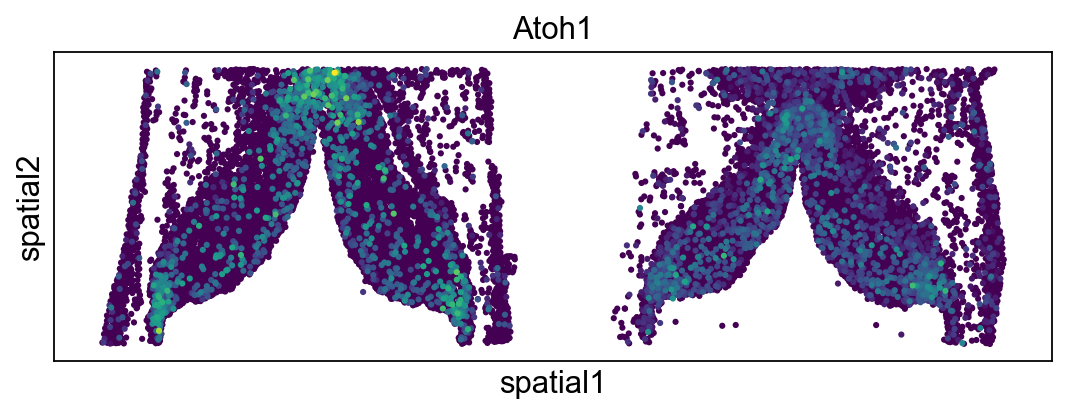

In [173]:
sc.pl.spatial(e13_3_4, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [176]:
e13_list = e13_data.obs['library_id'].unique()

In [177]:
e13_list

['e13_B1', 'e13_B3', 'e13_B5', 'e13_C5']
Categories (4, object): ['e13_B1', 'e13_B3', 'e13_B5', 'e13_C5']

AnnData object with n_obs × n_vars = 47025 × 1731
    obs: 'cell_number', 'library_id', 'timepoint', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'broad_cell_types', 'cell_types', 'batch'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial', 'spatial3d'
[[ 258.42797054 1496.62069728]
 [ 156.65507493 2131.67816197]
 [ 591.90976617 2712.7548042 ]
 [ 589.53978481 2746.16459227]
 [ 566.9626628  2677.89514068]
 [ 533.68070695 2572.98089562]
 [ 576.15223976 2762.6856912 ]
 [ 520.67132473 2529.12081616]
 [ 601.80102388 2961.38954355]
 [ 510.84092829 2608.49771588]]


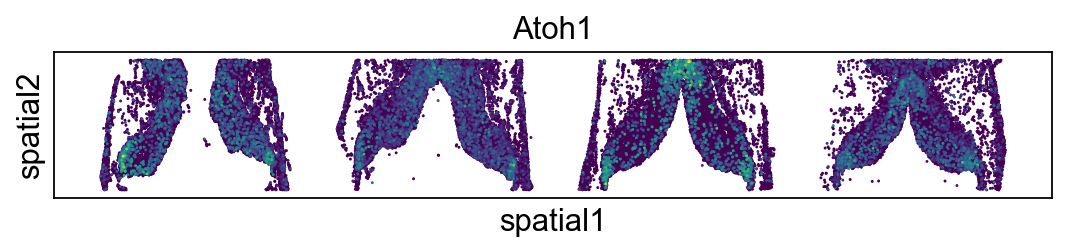

In [ ]:
import copy
import anndata as ad


# List of AnnData objects
adatas_list = [e13_1_2, e13_3_4]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 1200 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
e13_combined = ad.concat(adatas_list, join="outer", label="batch", keys=['e13_B1', 'e13_B3', 'e13_B5', 'e13_C5'])

# Verify the combined AnnData object
print(e13_combined)
print(e13_combined.obsm["spatial"][:10])

sc.pl.spatial(e13_combined, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [180]:
e13_combined.write("data_for_vitessce/e13_data.h5ad")

# E15

In [181]:
# Load data 
e15_data = ad.read_h5ad("data_for_vitessce/e15_data.h5ad")

e15_data

AnnData object with n_obs × n_vars = 70187 × 1732
    obs: 'cell_number', 'library_id', 'timepoint', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'broad_cell_types', 'cell_types'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'mean', 'std'
    uns: 'cell_types_colors', 'leiden_colors', 'library_id_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial', 'spatial3d'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [182]:
e15_data.obs['library_id'].unique()

['e15_C3', 'e15_D4', 'e15_D5']
Categories (3, object): ['e15_C3', 'e15_D4', 'e15_D5']

In [183]:
e15_C3 = e15_data[e15_data.obs['library_id'] == 'e15_C3'].copy()
e15_D4 = e15_data[e15_data.obs['library_id'] == 'e15_D4'].copy()
e15_D5 = e15_data[e15_data.obs['library_id'] == 'e15_D5'].copy()

In [ ]:
import copy
import anndata as ad


# List of AnnData objects
adatas_list = [e15_C3, e15_D4]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 1000 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
e15_3_4 = ad.concat(adatas_list, join="outer", label="batch", keys=["e15_C3", "e15_D4"])

# Verify the combined AnnData object
print(e15_3_4)
#print(e11_combined.obsm["spatial"][:10])

AnnData object with n_obs × n_vars = 45831 × 1732
    obs: 'cell_number', 'library_id', 'timepoint', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'broad_cell_types', 'cell_types', 'batch'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial', 'spatial3d'


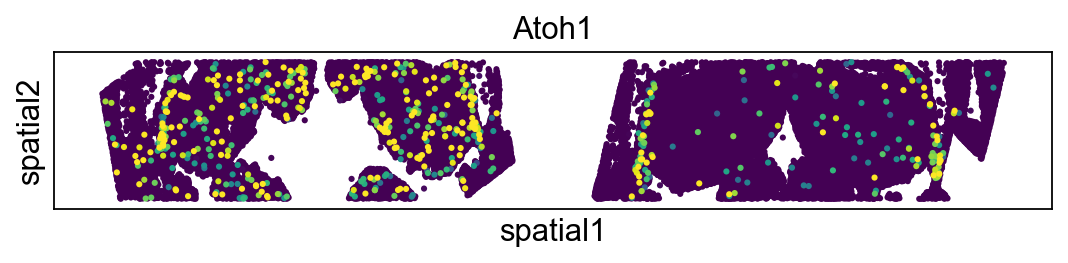

In [ ]:
sc.pl.spatial(e15_3_4, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [188]:
import copy
import anndata as ad


# List of AnnData objects
adatas_list = [e15_3_4, e15_D5]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 1000 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
e15_combined = ad.concat(adatas_list, join="outer", label="batch", keys=["e15_C3", "e15_D4", "e15_D5"])

# Verify the combined AnnData object
print(e15_combined)
#print(e11_combined.obsm["spatial"][:10])

AnnData object with n_obs × n_vars = 70187 × 1732
    obs: 'cell_number', 'library_id', 'timepoint', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'broad_cell_types', 'cell_types', 'batch'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial', 'spatial3d'


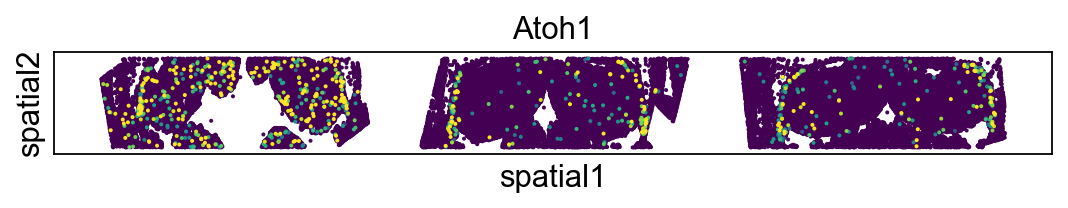

In [189]:
sc.pl.spatial(e15_combined, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [190]:
e15_combined.obs['library_id'].unique()

['e15_C3', 'e15_D4', 'e15_D5']
Categories (3, object): ['e15_C3', 'e15_D4', 'e15_D5']

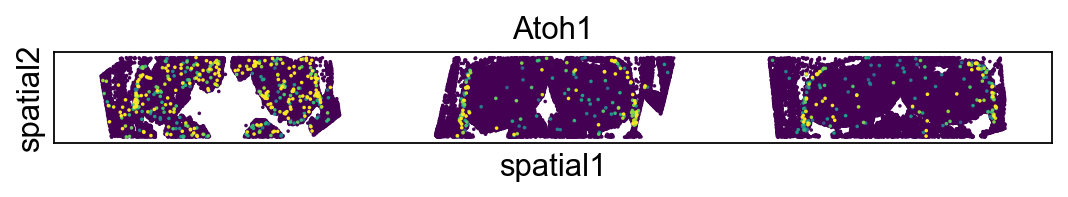

In [191]:
sc.pl.spatial(e15_data, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [192]:
e15_combined.write("data_for_vitessce/e15_data.h5ad")

# E17

In [2]:
# Load data 
e17_data = ad.read_h5ad("data_for_vitessce/e17_data.h5ad")

e17_data

AnnData object with n_obs × n_vars = 64717 × 1731
    obs: 'cell_number', 'library_id', 'timepoint', 'n_genes_by_counts', 'total_counts', 'n_genes', 'leiden', 'broad_cell_types', 'cell_types'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'mean', 'std'
    uns: 'cell_types_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial3d'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [3]:
e17_data.obs['library_id'].unique()

['e17_C4', 'e17_C5']
Categories (2, object): ['e17_C4', 'e17_C5']

In [4]:
e17_C4 = e17_data[e17_data.obs['library_id'] == 'e17_C4'].copy()
e17_C5 = e17_data[e17_data.obs['library_id'] == 'e17_C5'].copy()

In [5]:
import copy
import anndata as ad


# List of AnnData objects
adatas_list = [e17_C4, e17_C5]  # Replace with your actual AnnData objects

# Initialize the x-offset for horizontal alignment
x_offset = 0

# Adjust spatial coordinates for each dataset
for adata in adatas_list:
    # Extract spatial coordinates
    spatial = copy.deepcopy(adata.obsm["spatial"])
    x = spatial[:, 0]
    y = spatial[:, 1]

    # Normalize so that min_x and min_y are 0
    x_adjusted = x - x.min()
    y_adjusted = y - y.min()

    # Shift x-coordinates to horizontally append slices
    x_adjusted += x_offset

    # Update x_offset for the next dataset
    x_offset += x_adjusted.max() + 1000 # Add spacing between slices (e.g., 200)

    # Update the spatial coordinates in the dataset
    adata.obsm["spatial"][:, 0] = x_adjusted
    adata.obsm["spatial"][:, 1] = y_adjusted

# Concatenate the datasets into a single AnnData object
e17_combined = ad.concat(adatas_list, join="outer", label="batch", keys=["e17_C4", "e17_C5"])

# Verify the combined AnnData object
print(e17_combined)
#print(e11_combined.obsm["spatial"][:10])

AnnData object with n_obs × n_vars = 64717 × 1731
    obs: 'cell_number', 'library_id', 'timepoint', 'n_genes_by_counts', 'total_counts', 'n_genes', 'leiden', 'broad_cell_types', 'cell_types', 'batch'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial3d'


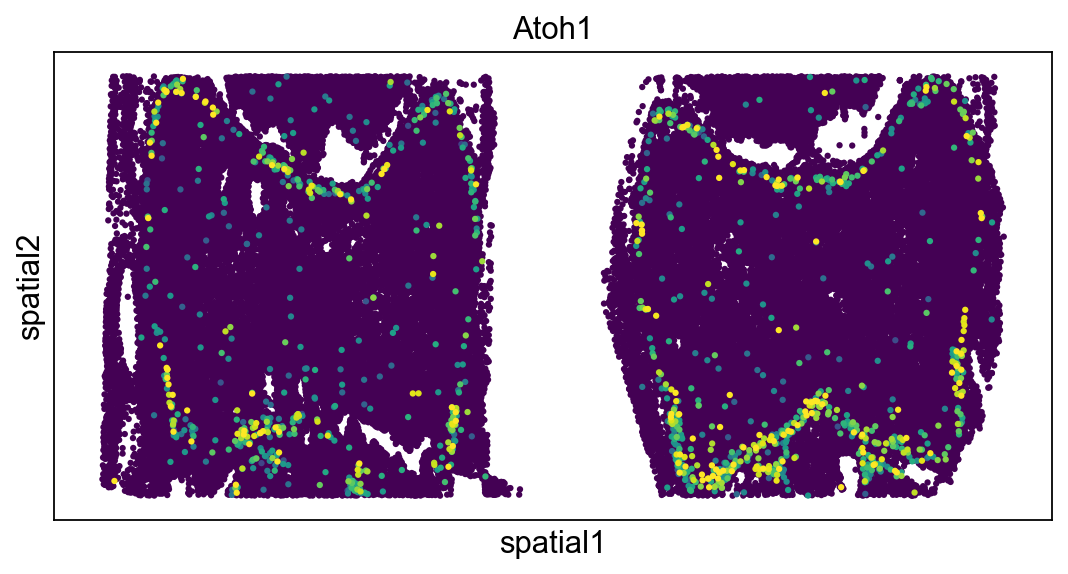

In [7]:
sc.pl.spatial(e17_combined, spot_size = 75, color = "Atoh1", colorbar_loc = None)

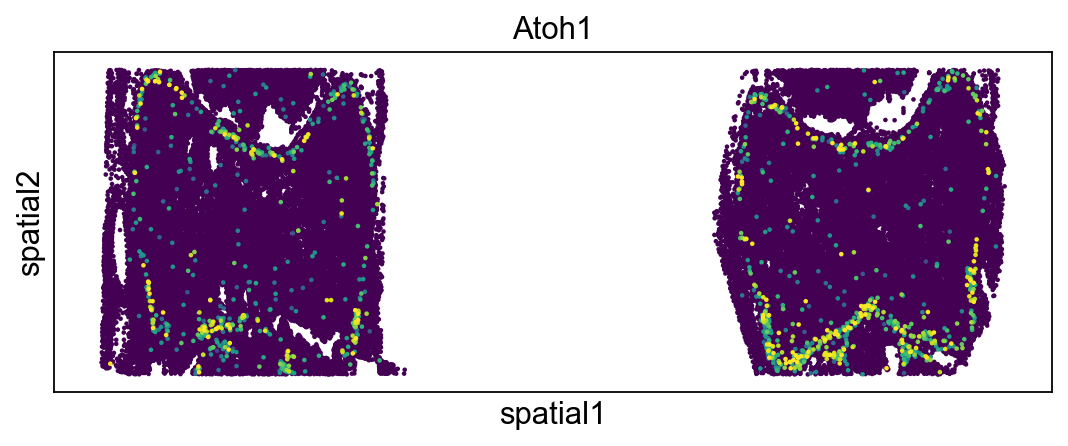

In [8]:
sc.pl.spatial(e17_data, spot_size = 75, color = "Atoh1", colorbar_loc = None)

In [9]:
e17_combined.write("data_for_vitessce/e17_data.h5ad")